## Imports

In [1]:
import matplotlib.pyplot as plt

from qiskit.circuit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator, QiskitRuntimeService, SamplerV2 as Sampler

from schwinger_hamiltonian import *

In [2]:
service = QiskitRuntimeService()
backend = service.backend(name='ibm_rensselaer')

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

sampler = Sampler(mode=backend)
sampler.options.default_shots = 8192

estimator = Estimator(mode=backend)
estimator.options.default_shots = 8192

qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-08-13 13:34:59,287: Default instance not set. Searching all available instances.


## Central Dogma of Adaptive Trotterization
The most important aspect that makes adaptive trotterization a viable algorithm for simulating complex systems is maximizing the time spent per step whilst keeping error rates low.

## Defining Step Limit

In [3]:
def sequential_search(dt: float) -> float:
  N = 1
  largest_step = 0
  step_reduction = 0.01
  flag = True
  i = 0
  longest_loop = 100

  while(flag and i >= longest_loop):
    if energy_function(dt) < 0:
      flag = False
    else:
      dt -= step_reduction
      i += 1

  return dt

In [4]:
def bisectional_search(dt: float) -> float:
  M = 1
  R = 1
  R_max = 100
  while(R < R_max and flag):
    

  return dt

IndentationError: expected an indented block after 'while' statement on line 5 (11531244.py, line 8)

In [7]:
test_circ = QuantumCircuit(3)
test_results = []

for i in range(20):
  test_circ.h(0)
  test_circ.h(1)
  test_circ.h(2)
  test_circ.cx(0, 1)
  test_circ.cx(1, 2)
  test_circ.rz(np.pi / 12, 2)
  test_circ.cx(1, 2)
  test_circ.cx(0, 1)
  test_circ.h(0)
  test_circ.h(1)
  test_circ.h(2)
  test_circ.measure_all()

  isa_test_circ = pm.run(test_circ)
  test_hamiltonian = SparsePauliOp.from_list([("ZII", 1), ("IZI", 1), ("IIZ", 1)])
  test_hamiltonian = test_hamiltonian.apply_layout(isa_test_circ.layout)

  test_job = estimator.run([(isa_test_circ, test_hamiltonian)])
  test_result = test_job.result()
  print(f"Energy: {test_result[0].data.evs}\tDeviation: {test_result[0].data.stds}")
  test_results.append(test_result)

Energy: 2.770980268082595	Deviation: 0.007745486835356738
Energy: 2.564085930798795	Deviation: 0.010707791956930423
Energy: 2.388685298654929	Deviation: 0.011253739445086269
Energy: 2.24528640615733	Deviation: 0.013260424233400542
Energy: 2.0863737661013646	Deviation: 0.014490647354555802
Energy: 1.9633346623908952	Deviation: 0.012439540599109353
Energy: 1.856460972066567	Deviation: 0.014971074824386733
Energy: 1.7376150990369232	Deviation: 0.015284953029717437
Energy: 1.6010299844558469	Deviation: 0.017176123380850866
Energy: 1.5843506056821124	Deviation: 0.016711743576491963
Energy: 1.4054726671100553	Deviation: 0.018011215343321625
Energy: 1.3123861575979445	Deviation: 0.01760777122371871
Energy: 1.2540638285821148	Deviation: 0.01648500053590414
Energy: 1.1940715858459678	Deviation: 0.018111674802283272
Energy: 1.1471281217481064	Deviation: 0.018890639780463278
Energy: 1.1050129417580865	Deviation: 0.016948621948942068
Energy: 0.9791099926817456	Deviation: 0.019391536057277295
Energ

In [13]:
energies = [result[0].data.evs for result in test_results]

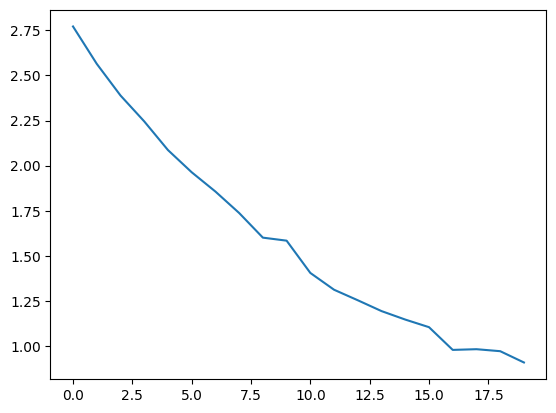

In [15]:
plt.plot(energies)

In [26]:
test_results[0][0].data.evs

array(2.73060241)

In [28]:
for i in range(2):
  print(test_results[i][0].data.evs)
  print(test_results[i][0].data.stds)

2.730602406561675
0.00967598007866638
2.54301856749667
0.011178231253036582


This is a function that steps forward the trotterization circuit by one time step

In [5]:
def step_forward_ising(circ: QuantumCircuit) -> None:
  circ.h(0)
  circ.h(1)
  circ.h(2)
  circ.cx(0, 1)
  circ.cx(1, 2)
  circ.rz(np.pi / 12, 2)
  circ.cx(1, 2)
  circ.cx(0, 1)
  circ.h(0)
  circ.h(1)
  circ.h(2)

## Ising Model Trial
The Ising Model is one of the easiest systems to simulate, as it is just a 1D chain of spins.

In [13]:
# Variable initialization
perm_circ = QuantumCircuit(3)
temp_circ = QuantumCircuit(3)
step = 1
ising_hamiltonian = SparsePauliOp.from_list([("ZII", 1), ("IZI", 1), ("IIZ", 1)])
results = []

# The first time step
temp_circ.measure_all()
isa_temp_circ = pm.run(temp_circ)
isa_hamiltonian = ising_hamiltonian.apply_layout(isa_temp_circ.layout)
job = estimator.run([(isa_temp_circ, isa_hamiltonian)])
result = job.result()
results.append(result)
print(f"Time stepped: {result[0].data.evs}\tDeviation: {result[0].data.stds}")

for step in range(1, 20):
  flag = True
  temp_steps = 0
  print(f"Starting temp step {step}")
  temp_results = []
  temp_results.append(results[len(results) - 1])

  while(flag):
    if (temp_steps == 3):
      break
    step_forward_ising(temp_circ)
    temp_steps += 1
    perm_circ = temp_circ
    temp_circ.measure_all()

    isa_temp_circ = pm.run(temp_circ)
    isa_hamiltonian = ising_hamiltonian.apply_layout(isa_temp_circ.layout)

    temp_job = estimator.run([(isa_temp_circ, isa_hamiltonian)])
    temp_result = temp_job.result()
    print(f"Time stepped: {temp_result[0].data.evs}\tDeviation: {temp_result[0].data.stds}")

    if (abs(temp_result[0].data.evs - temp_results[len(temp_results) - 1][0].data.evs)> 0.25 or
        abs(temp_result[0].data.evs - temp_results[len(temp_results) - 1][0].data.evs)< 0.15):
      flag = False
      result = temp_result
      print(f"Difference: {temp_result[0].data.evs} and {temp_results[len(temp_results) - 1][0].data.evs}")
      print("Finished temp step")
      break
      
    temp_circ = perm_circ
    temp_results.append(temp_result)
    result = temp_result

  results.append(result)

Time stepped: 3.0259887293721563	Deviation: 0.003614474078803796
Starting temp step 1
Time stepped: 2.7004648816656784	Deviation: 0.00875081401826432
Difference: 2.7004648816656784 and 3.0259887293721563
Finished temp step
Starting temp step 2
Time stepped: 2.445252986484033	Deviation: 0.010985212339331892
Difference: 2.445252986484033 and 2.7004648816656784
Finished temp step
Starting temp step 3
Time stepped: 2.280182506759184	Deviation: 0.01377471784105975
Time stepped: 2.2831698318920814	Deviation: 0.012900510711354016
Difference: 2.2831698318920814 and 2.280182506759184
Finished temp step
Starting temp step 4
Time stepped: 2.172613307605536	Deviation: 0.01333240199659555
Difference: 2.172613307605536 and 2.2831698318920814
Finished temp step
Starting temp step 5
Time stepped: 2.0133694999824847	Deviation: 0.012216308438430924
Time stepped: 2.0247288906941576	Deviation: 0.012564441957446265
Difference: 2.0247288906941576 and 2.0133694999824847
Finished temp step
Starting temp step 

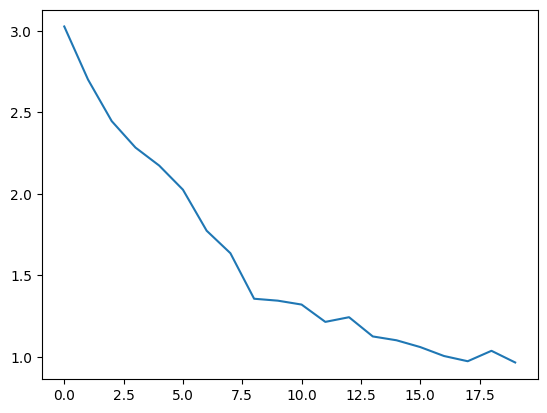

In [16]:
energies = [result[0].data.evs for result in results]
plt.plot(energies)

## N=4 Circuit Construction

In [9]:
# Model parameters
N = 4
m = 1
a = 1
g = 0
J = 0.5*g*g*a

# Backend parameters
t_start = 0
t_max = 3
dt = 0.2
shots = 10000
time_step_max = int(t_max/dt)
#time_step_list = np.linspace(t_start, t_max, (int((t_max - t_start)/dt))+1)

# quantum and measurement circuits
qr = QuantumRegister(N)
cr = ClassicalRegister(N)
qc = QuantumCircuit(qr,cr)
qc_meas = QuantumCircuit(qr,cr)
qc_meas.measure(qr,cr)

# initial state prep
for i in range(int(N/2)):
  qc.x(qr[2*i+1])

time_list = []
cc_list_n4_g0 = []
elec_list_n4_g0 = []
circuit_depth_list = []
evolution_steps = []

for time_step in range(time_step_max+1):
    print("Time = ", dt*time_step)

    # H_{XX+YY} kinetic term
    for i in range(N-1):
        qc.cx(qr[i], qr[i+1])
        qc.h(qr[i])
        qc.cx(qr[i], qr[i+1])

        qc.rz((0.5/a)*dt, qr[i])
        qc.rz(-(0.5/a)*dt, qr[i+1])

        qc.cx(qr[i], qr[i+1])
        qc.h(qr[i])
        qc.cx(qr[i], qr[i+1])

    # H_Z mass term
    for i in range(N):
        qc.rz(m*((-1)**(i+1))*dt, qr[i])

    # H_ZZ electric field term
    for i in range(1, N-1):
        for k in range(0, i):
            for l in range(k+1, i+1):
                qc.rzz(J*dt, qr[k], qr[l])

    # H_Z electric field term
    for n in range(N-1):
        qc.rz(-0.5*J*dt*(N-(n+1)-0.5*(-1+(-1)**(n+1))), qr[n])

    qc_total = qc.compose(qc_meas)
    evolution_steps.append(qc_total)


Time =  0.0
Time =  0.2
Time =  0.4
Time =  0.6000000000000001
Time =  0.8
Time =  1.0
Time =  1.2000000000000002
Time =  1.4000000000000001
Time =  1.6
Time =  1.8
Time =  2.0
Time =  2.2
Time =  2.4000000000000004
Time =  2.6
Time =  2.8000000000000003
Time =  3.0
